# AI Workforce Survey Analysis (Survey-First)

**Notebook purpose**: Survey-first descriptive analysis of Survation Jan 2026 results (N=2,016), including sector patterns, reported AI uses, perceived outcomes, sentiment, and barriers/rejection.

**Validation role**: Prepare clean task-use tables and an open-text task corpus for later mapping to O*NET task statements (taxonomy alignment).

**Out of scope**: Any "AI exposure" or "automation risk" analysis using external exposure scores. This notebook does not join SOC/O*NET exposure measures or interpret sectors through exposure frameworks.

In [1]:
#|hide
import nblite; from nbdev.showdoc import show_doc; nblite.nbl_export()

/Users/bhargav/adu_dev/aisi-economy-index/.venv/lib/python3.11/site-packages/nbformat/__init__.py:96: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)


In [2]:
import aisi_economy_index as proj
from aisi_economy_index import const

In [3]:
import json
import asyncio
from typing import Optional, Tuple, Dict, Any, List
import adulib.llm as llm
import inspect

In [4]:
from dotenv import load_dotenv

load_dotenv() 

True

In [5]:
from pydantic import BaseModel, ValidationError, conint, confloat


In [6]:
from pathlib import Path


In [7]:
# =============================================================================
# 1. SETUP AND PATHS
# =============================================================================
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Paths
BASE = Path(".")
DATA_DIR = BASE / "data"
SURVEY_PATH = DATA_DIR / "Autonomy - Final Raw Data - Survation.xlsx"

# Output directories - survey-only outputs
OUT_DIR = BASE / "outputs" / "survey_only"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Survey file exists: {SURVEY_PATH.exists()}")
print(f"Output directory: {OUT_DIR}")

# =============================================================================
# SLIDE-READY PLOT SETTINGS
# =============================================================================
plt.rcParams.update({
    'figure.figsize': (12, 7),
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'font.size': 13,
    'axes.titlesize': 18,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
})

# Color palette
SECTOR_COLORS = {
    'Information Technology (IT)': '#3498DB',
    'Financial Services': '#2ECC71',
    'Education': '#9B59B6',
    'Healthcare Services': '#E74C3C'
}
PRIMARY_COLOR = '#2C3E50'
ACCENT_COLOR = '#E74C3C'
SECONDARY_COLOR = '#3498DB'

print("Setup complete.")

Survey file exists: True
Output directory: outputs/survey_only
Setup complete.


In [8]:
# =============================================================================
# 2. LOAD SURVEY DATA
# =============================================================================
survey = pd.read_excel(SURVEY_PATH)
print(f"Survey loaded: {len(survey):,} responses, {len(survey.columns)} columns")

Survey loaded: 2,016 responses, 126 columns


In [9]:
# =============================================================================
# 3. LABEL MAPPINGS
# =============================================================================

# Q6 Task usage labels (q6.a.1 through q6.a.9)
Q6_LABELS = {
    'q6.a.1': 'Drafting and editing documents',
    'q6.a.2': 'Data analysis and visualisation',
    'q6.a.3': 'Searching for and summarising information',
    'q6.a.4': 'Administrative tasks',
    'q6.a.5': 'Communication support',
    'q6.a.6': 'Creative work',
    'q6.a.7': 'Technical/specialised outputs',
    'q6.a.8': 'Professional development',
    'q6.a.9': 'Other',
}

# Q12 Rejection reason labels
Q12_LABELS = {
    'q12.a.1': 'Too expensive / poor value',
    'q12.a.2': "Didn't meet needs / lacked features",
    'q12.a.3': 'Difficult to use / integrate',
    'q12.a.4': "Didn't trust accuracy / reliability",
    'q12.a.5': 'Data security concerns',
    'q12.a.6': "Organisation didn't support / allow",
    'q12.a.7': 'Prefer alternative tools / approaches',
    'q12.a.8': 'Took too long to learn',
    'q12.a.9': 'Colleagues advised against',
    'q12.a.10': 'Found better alternative tool',
    'q12.a.11': 'Too many superfluous outputs',
    'q12.a.12': 'Ethical / environmental concerns',
    'q12.a.13': 'Other',
}

# Q11 exact category strings (used for exact matching, no keywords)
TRIED_REJECTED = "I have tried an AI tool and decided against adopting/using it"
NEVER_TRIED = "I have never tried an AI tool and decided against adopting/using it"
CANT_REMEMBER = "I can't remember"

# Key column names
SECTOR_COL = 'sector.a'
Q1_COL = 'q1.a'
Q4_COL = 'q4.a'
Q9_COL = 'q9.a'
Q11_COL = 'q11.a'
Q13_OPEN_COL = 'q13_open_text.a.1'
Q14_OPEN_COL = 'q14_open_text.a.1'

# Sentiment response strings (for exact matching)
EXTREMELY_POSITIVE = 'Extremely positive'
SOMEWHAT_POSITIVE = 'Somewhat positive'

# Productivity response string (for exact matching)
MORE_PRODUCTIVE = 'AI tools have helped me become more productive at work'

print("Label mappings defined.")

Label mappings defined.


In [10]:
# =============================================================================
# 3a. ENCODING CHECKS: Q6 COLUMNS
# =============================================================================
# Verify Q6 encoding: confirm q6.a.X uses NaN for unselected and non-null for selected
# Also check if q6_other columns exist and how "Other" is encoded

print("Q6 ENCODING CHECK")
print("=" * 60)

# Find all Q6-related columns
q6_all_cols = [c for c in survey.columns if c.startswith('q6')]
print(f"\nAll Q6-related columns in survey: {len(q6_all_cols)}")
for col in sorted(q6_all_cols):
    print(f"  {col}")

# Check value distribution for first few Q6 task columns
print("\nQ6 value samples (first 3 task columns):")
for col in ['q6.a.1', 'q6.a.2', 'q6.a.3']:
    if col in survey.columns:
        vc = survey[col].value_counts(dropna=False).head(5)
        print(f"\n  {col}:")
        for val, cnt in vc.items():
            print(f"    {repr(val)}: {cnt}")

# Check q6.a.9 specifically (is this "Other" or is there q6_other?)
print("\nQ6 'Other' encoding check:")
if 'q6.a.9' in survey.columns:
    print(f"  q6.a.9 value counts:")
    vc = survey['q6.a.9'].value_counts(dropna=False)
    for val, cnt in vc.items():
        print(f"    {repr(val)}: {cnt}")

# Check for q6_other columns
q6_other_cols = [c for c in survey.columns if 'q6_other' in c.lower() or 'q6.other' in c.lower()]
if q6_other_cols:
    print(f"\n  q6_other columns found: {q6_other_cols}")
    for col in q6_other_cols[:2]:
        print(f"  {col} sample values:")
        for val in survey[col].dropna().head(3):
            print(f"    {repr(str(val)[:50])}")
else:
    print(f"\n  No q6_other columns found - 'Other' appears to be q6.a.9")

# Confirm encoding: NaN = unselected, non-null = selected
print("\nEncoding confirmation:")
for col in ['q6.a.1', 'q6.a.2']:
    if col in survey.columns:
        non_null = survey[col].notna().sum()
        total = len(survey)
        print(f"  {col}: {non_null}/{total} non-null ({round(non_null/total*100, 1)}%)")

Q6 ENCODING CHECK

All Q6-related columns in survey: 10
  q6.a.1
  q6.a.2
  q6.a.3
  q6.a.4
  q6.a.5
  q6.a.6
  q6.a.7
  q6.a.8
  q6.a.9
  q6_other.a.1

Q6 value samples (first 3 task columns):

  q6.a.1:
    nan: 1129
    'Drafting and editing documents': 887

  q6.a.2:
    nan: 1132
    'Data analysis and visualisation': 884

  q6.a.3:
    'Searching for and summarising information': 1127
    nan: 889

Q6 'Other' encoding check:
  q6.a.9 value counts:
    nan: 1907
    'Other': 109

  q6_other columns found: ['q6_other.a.1']
  q6_other.a.1 sample values:
    'Health care'
    'I havent used ai'
    'none at all'

Encoding confirmation:
  q6.a.1: 887/2016 non-null (44.0%)
  q6.a.2: 884/2016 non-null (43.8%)


In [11]:
# =============================================================================
# 3b. ENCODING CHECKS: Q12 COLUMNS
# =============================================================================
# Verify Q12 encoding and check for any unmapped columns

print("Q12 ENCODING CHECK")
print("=" * 60)

# Find all Q12-related columns in survey
q12_all_cols = [c for c in survey.columns if c.startswith('q12')]
print(f"\nAll Q12-related columns in survey: {len(q12_all_cols)}")
for col in sorted(q12_all_cols):
    in_labels = "MAPPED" if col in Q12_LABELS else "UNMAPPED"
    print(f"  {col} [{in_labels}]")

# Identify unmapped Q12 columns
q12_unmapped = [c for c in q12_all_cols if c not in Q12_LABELS]
if q12_unmapped:
    print(f"\nWARNING: {len(q12_unmapped)} unmapped Q12 columns:")
    for col in q12_unmapped:
        print(f"  {col}")
        # Show sample values
        sample = survey[col].dropna().head(3).tolist()
        if sample:
            print(f"    Sample values: {sample[:2]}")
    
    # Export unmapped columns list
    unmapped_path = OUT_DIR / "q12_unmapped_columns.txt"
    with open(unmapped_path, 'w') as f:
        f.write("Unmapped Q12 columns in survey data\n")
        f.write("=" * 40 + "\n\n")
        for col in q12_unmapped:
            f.write(f"{col}\n")
    print(f"\nSaved unmapped columns to: {unmapped_path}")
else:
    print(f"\nAll Q12 columns are mapped in Q12_LABELS")

# Check encoding for Q12 (NaN = unselected)
print("\nQ12 encoding check (first 3 reason columns):")
for col in ['q12.a.1', 'q12.a.2', 'q12.a.3']:
    if col in survey.columns:
        vc = survey[col].value_counts(dropna=False).head(3)
        print(f"\n  {col} ({Q12_LABELS.get(col, 'Unknown')}):")
        for val, cnt in vc.items():
            print(f"    {repr(val)}: {cnt}")

Q12 ENCODING CHECK

All Q12-related columns in survey: 14
  q12.a.1 [MAPPED]
  q12.a.10 [MAPPED]
  q12.a.11 [MAPPED]
  q12.a.12 [MAPPED]
  q12.a.13 [MAPPED]
  q12.a.2 [MAPPED]
  q12.a.3 [MAPPED]
  q12.a.4 [MAPPED]
  q12.a.5 [MAPPED]
  q12.a.6 [MAPPED]
  q12.a.7 [MAPPED]
  q12.a.8 [MAPPED]
  q12.a.9 [MAPPED]
  q12_other.a.1 [UNMAPPED]

  q12_other.a.1
    Sample values: ['While the accuracy of some were accurate, some were far from accurate.', 'It was actually a mistake. I adopted AI into my daily work life and activities.']

Saved unmapped columns to: outputs/survey_only/q12_unmapped_columns.txt

Q12 encoding check (first 3 reason columns):

  q12.a.1 (Too expensive / poor value):
    nan: 1920
    'It was too expensive/poor value for money': 96

  q12.a.2 (Didn't meet needs / lacked features):
    nan: 1806
    'It didn’t meet my needs/lacked key features': 210

  q12.a.3 (Difficult to use / integrate):
    nan: 1856
    'It was difficult to use/integrate into my work': 160


## A. Sample and Sector Composition

In [12]:
# =============================================================================
# A.1 TOTAL N AND SECTOR DISTRIBUTION
# =============================================================================
total_n = len(survey)
print(f"Total N: {total_n:,}")

# Sector counts and percentages
sector_counts = survey[SECTOR_COL].value_counts()
sector_pct = (sector_counts / total_n * 100).round(1)

sector_df = pd.DataFrame({
    'Sector': sector_counts.index,
    'N': sector_counts.values,
    'Percent': sector_pct.values
})

print("\nSector Composition:")
print(sector_df.to_string(index=False))

# Save
sector_df.to_csv(OUT_DIR / "sector_counts.csv", index=False)
print(f"\nSaved: {OUT_DIR / 'sector_counts.csv'}")

Total N: 2,016

Sector Composition:
                     Sector   N  Percent
Information Technology (IT) 834     41.4
                  Education 434     21.5
         Financial Services 381     18.9
        Healthcare Services 367     18.2

Saved: outputs/survey_only/sector_counts.csv


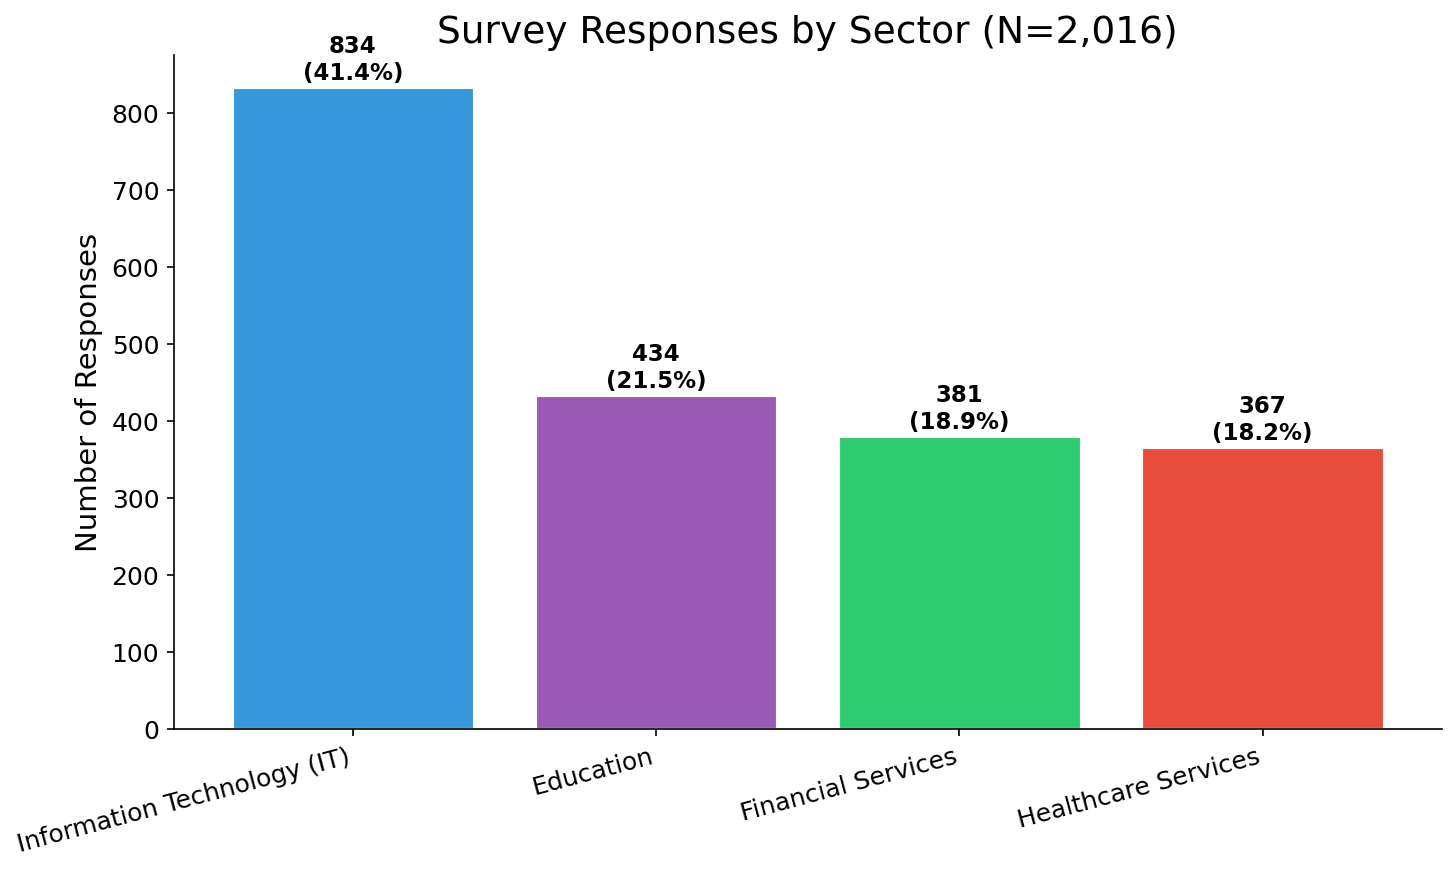

In [13]:
# =============================================================================
# A.2 SECTOR BAR CHART
# =============================================================================
fig, ax = plt.subplots(figsize=(10, 6))

sectors = sector_df['Sector'].values
counts = sector_df['N'].values
colors = [SECTOR_COLORS.get(s, '#7F8C8D') for s in sectors]

bars = ax.bar(range(len(sectors)), counts, color=colors, edgecolor='white', linewidth=1.5)

ax.set_ylabel('Number of Responses', fontsize=14)
ax.set_title('Survey Responses by Sector (N=2,016)', fontsize=18)

# Proper tick label handling: set ticks BEFORE labels
ax.set_xticks(range(len(sectors)))
ax.set_xticklabels(sectors, rotation=15, ha='right')

for bar, count, pct in zip(bars, counts, sector_df['Percent'].values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'{int(count):,}\n({pct}%)', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(OUT_DIR / "fig_sector_composition.png", dpi=150, bbox_inches='tight')
plt.show()

## B. Organisational Enablement (Q1)

In [14]:
# =============================================================================
# B.1 Q1 OVERALL DISTRIBUTION
# =============================================================================
q1_overall = survey[Q1_COL].value_counts()
q1_overall_pct = (q1_overall / total_n * 100).round(1)

q1_overall_df = pd.DataFrame({
    'Response': q1_overall.index,
    'N': q1_overall.values,
    'Percent': q1_overall_pct.values
})

print("Q1: Does your organisation encourage or discourage AI adoption?")
print(q1_overall_df.to_string(index=False))

# Save
q1_overall_df.to_csv(OUT_DIR / "q1_org_encouragement_overall.csv", index=False)
print(f"\nSaved: {OUT_DIR / 'q1_org_encouragement_overall.csv'}")

Q1: Does your organisation encourage or discourage AI adoption?
                                      Response   N  Percent
               Strongly encourages AI adoption 909     45.1
               Somewhat encourages AI adoption 562     27.9
Neither encourages nor discourages AI adoption 335     16.6
              Somewhat discourages AI adoption  88      4.4
              Strongly discourages AI adoption  71      3.5
                                    Don’t know  51      2.5

Saved: outputs/survey_only/q1_org_encouragement_overall.csv


In [15]:
# =============================================================================
# B.2 Q1 BY SECTOR
# =============================================================================
q1_by_sector = pd.crosstab(
    survey[SECTOR_COL], 
    survey[Q1_COL], 
    normalize='index'
) * 100

print("Q1 by Sector (% within sector):")
print(q1_by_sector.round(1))

# Save
q1_by_sector.round(1).to_csv(OUT_DIR / "q1_org_encouragement_by_sector.csv")
print(f"\nSaved: {OUT_DIR / 'q1_org_encouragement_by_sector.csv'}")

Q1 by Sector (% within sector):
q1.a                         Don’t know  \
sector.a                                  
Education                           5.8   
Financial Services                  1.0   
Healthcare Services                 5.7   
Information Technology (IT)         0.1   

q1.a                         Neither encourages nor discourages AI adoption  \
sector.a                                                                      
Education                                                              31.1   
Financial Services                                                      9.7   
Healthcare Services                                                    35.7   
Information Technology (IT)                                             3.8   

q1.a                         Somewhat discourages AI adoption  \
sector.a                                                        
Education                                                 6.9   
Financial Services                     

## C. Sentiment (Q4)

In [16]:
# =============================================================================
# C.1 Q4 OVERALL DISTRIBUTION
# =============================================================================
q4_overall = survey[Q4_COL].value_counts()
q4_overall_pct = (q4_overall / total_n * 100).round(1)

q4_overall_df = pd.DataFrame({
    'Response': q4_overall.index,
    'N': q4_overall.values,
    'Percent': q4_overall_pct.values
})

print("Q4: How positive or negative do you feel about AI in your work?")
print(q4_overall_df.to_string(index=False))

# Calculate positive sentiment using EXACT MATCHING (not substring)
# This avoids counting "Neither positive nor negative" as positive
positive_responses = [EXTREMELY_POSITIVE, SOMEWHAT_POSITIVE]
positive_mask = survey[Q4_COL].isin(positive_responses)
positive_sentiment = positive_mask.sum()
positive_pct = round(positive_sentiment / total_n * 100, 1)
print(f"\nPositive sentiment (Extremely + Somewhat positive): {positive_sentiment:,} ({positive_pct}%)")

# Also calculate negative and neutral for completeness
negative_responses = ['Extremely negative', 'Somewhat negative']
negative_mask = survey[Q4_COL].isin(negative_responses)
negative_sentiment = negative_mask.sum()
negative_pct = round(negative_sentiment / total_n * 100, 1)
print(f"Negative sentiment (Extremely + Somewhat negative): {negative_sentiment:,} ({negative_pct}%)")

neutral_response = 'Neither positive nor negative'
neutral_sentiment = (survey[Q4_COL] == neutral_response).sum()
neutral_pct = round(neutral_sentiment / total_n * 100, 1)
print(f"Neutral sentiment: {neutral_sentiment:,} ({neutral_pct}%)")

# Save
q4_overall_df.to_csv(OUT_DIR / "q4_sentiment_overall.csv", index=False)
print(f"\nSaved: {OUT_DIR / 'q4_sentiment_overall.csv'}")

Q4: How positive or negative do you feel about AI in your work?
                     Response   N  Percent
            Somewhat positive 785     38.9
           Extremely positive 746     37.0
Neither positive nor negative 258     12.8
            Somewhat negative 129      6.4
                   Don’t know  56      2.8
           Extremely negative  42      2.1

Positive sentiment (Extremely + Somewhat positive): 1,531 (75.9%)
Negative sentiment (Extremely + Somewhat negative): 171 (8.5%)
Neutral sentiment: 258 (12.8%)

Saved: outputs/survey_only/q4_sentiment_overall.csv


In [17]:
# =============================================================================
# C.2 Q4 BY SECTOR
# =============================================================================
q4_by_sector = pd.crosstab(
    survey[SECTOR_COL], 
    survey[Q4_COL], 
    normalize='index'
) * 100

print("Q4 Sentiment by Sector (% within sector):")
print(q4_by_sector.round(1))

# Save
q4_by_sector.round(1).to_csv(OUT_DIR / "q4_sentiment_by_sector.csv")
print(f"\nSaved: {OUT_DIR / 'q4_sentiment_by_sector.csv'}")

Q4 Sentiment by Sector (% within sector):
q4.a                         Don’t know  Extremely negative  \
sector.a                                                      
Education                           5.1                 3.9   
Financial Services                  1.0                 1.8   
Healthcare Services                 6.8                 2.7   
Information Technology (IT)         0.6                 1.0   

q4.a                         Extremely positive  \
sector.a                                          
Education                                  18.4   
Financial Services                         40.4   
Healthcare Services                        16.9   
Information Technology (IT)                54.0   

q4.a                         Neither positive nor negative  Somewhat negative  \
sector.a                                                                        
Education                                             21.2               11.5   
Financial Services           

## D. Task Usage Categories (Q6)

In [18]:
# =============================================================================
# D.1 Q6 TASK USAGE - LABELED, BY SECTOR
# =============================================================================

# Get Q6 task columns (q6.a.1 through q6.a.9, NOT q6_other)
q6_task_cols = [f'q6.a.{i}' for i in range(1, 10) if f'q6.a.{i}' in survey.columns]

print(f"Q6 task columns detected: {len(q6_task_cols)}")
for col in q6_task_cols:
    label = Q6_LABELS.get(col, col)
    print(f"  {col} -> {label}")

# Calculate usage rates by sector
q6_by_sector_rows = []

for sector in survey[SECTOR_COL].dropna().unique():
    sector_df_temp = survey[survey[SECTOR_COL] == sector]
    sector_n = len(sector_df_temp)
    
    row = {'Sector': sector, 'N': sector_n}
    
    for col in q6_task_cols:
        # Count non-null responses (respondent selected this task category)
        usage_count = sector_df_temp[col].notna().sum()
        usage_pct = round(usage_count / sector_n * 100, 1) if sector_n > 0 else 0
        label = Q6_LABELS.get(col, col)
        row[label] = usage_pct
    
    q6_by_sector_rows.append(row)

q6_by_sector_df = pd.DataFrame(q6_by_sector_rows)

print("\nQ6 Task Usage by Sector (%):")
print(q6_by_sector_df.to_string(index=False))

# Save
q6_by_sector_df.to_csv(OUT_DIR / "q6_task_use_by_sector.csv", index=False)
print(f"\nSaved: {OUT_DIR / 'q6_task_use_by_sector.csv'}")

Q6 task columns detected: 9
  q6.a.1 -> Drafting and editing documents
  q6.a.2 -> Data analysis and visualisation
  q6.a.3 -> Searching for and summarising information
  q6.a.4 -> Administrative tasks
  q6.a.5 -> Communication support
  q6.a.6 -> Creative work
  q6.a.7 -> Technical/specialised outputs
  q6.a.8 -> Professional development
  q6.a.9 -> Other

Q6 Task Usage by Sector (%):
                     Sector   N  Drafting and editing documents  Data analysis and visualisation  Searching for and summarising information  Administrative tasks  Communication support  Creative work  Technical/specialised outputs  Professional development  Other
        Healthcare Services 367                            34.1                             25.3                                       45.8                  32.2                   30.0           30.5                           16.1                      33.5   12.5
         Financial Services 381                            49.3                    

In [19]:
# =============================================================================
# D.2 Q6 TASK BREADTH INDEX
# =============================================================================

# Count number of task categories selected per respondent
survey['q6_task_breadth'] = survey[q6_task_cols].notna().sum(axis=1)

# Distribution
breadth_dist = survey['q6_task_breadth'].value_counts().sort_index()

print("Task Breadth Distribution (number of Q6 categories selected per respondent):")
for n_tasks, count in breadth_dist.items():
    pct = round(count / total_n * 100, 1)
    print(f"  {n_tasks} tasks: {count:,} ({pct}%)")

# Overall mean
overall_mean_breadth = survey['q6_task_breadth'].mean()
print(f"\nOverall mean task breadth: {overall_mean_breadth:.2f}")

# Mean by sector
breadth_by_sector = survey.groupby(SECTOR_COL)['q6_task_breadth'].agg(['mean', 'std', 'count']).round(2)
breadth_by_sector.columns = ['Mean_Breadth', 'Std_Breadth', 'N']

print("\nTask Breadth by Sector:")
print(breadth_by_sector)

# Save
breadth_df = pd.DataFrame({
    'Tasks_Selected': breadth_dist.index,
    'N': breadth_dist.values,
    'Percent': np.round(breadth_dist.values / total_n * 100, 1)
})
breadth_df.to_csv(OUT_DIR / "q6_task_breadth.csv", index=False)
breadth_by_sector.to_csv(OUT_DIR / "q6_task_breadth_by_sector.csv")
print(f"\nSaved: {OUT_DIR / 'q6_task_breadth.csv'}")
print(f"Saved: {OUT_DIR / 'q6_task_breadth_by_sector.csv'}")

Task Breadth Distribution (number of Q6 categories selected per respondent):
  1 tasks: 432 (21.4%)
  2 tasks: 254 (12.6%)
  3 tasks: 399 (19.8%)
  4 tasks: 321 (15.9%)
  5 tasks: 242 (12.0%)
  6 tasks: 154 (7.6%)
  7 tasks: 93 (4.6%)
  8 tasks: 119 (5.9%)
  9 tasks: 2 (0.1%)

Overall mean task breadth: 3.56

Task Breadth by Sector:
                             Mean_Breadth  Std_Breadth    N
sector.a                                                   
Education                            2.75         1.88  434
Financial Services                   3.86         1.99  381
Healthcare Services                  2.60         1.78  367
Information Technology (IT)          4.27         1.98  834

Saved: outputs/survey_only/q6_task_breadth.csv
Saved: outputs/survey_only/q6_task_breadth_by_sector.csv


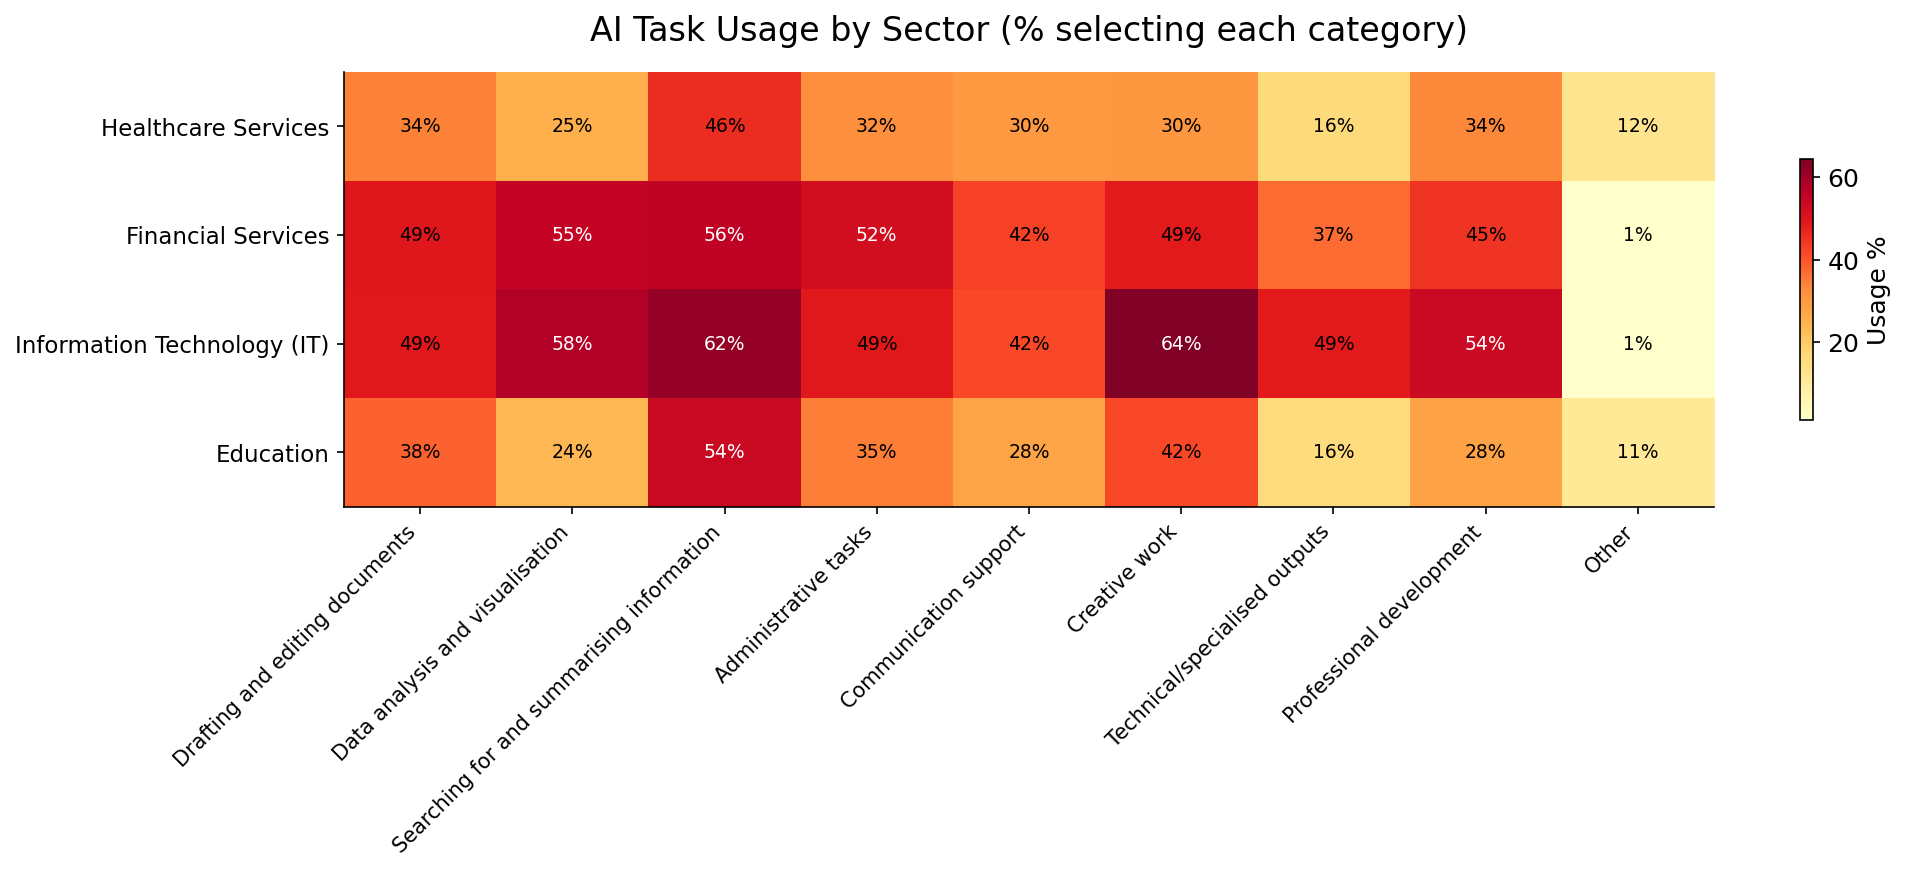

In [20]:
# =============================================================================
# D.3 Q6 TASK USAGE HEATMAP
# =============================================================================
# Prepare heatmap data with labeled columns
heatmap_cols = [Q6_LABELS.get(col, col) for col in q6_task_cols]
heatmap_data = q6_by_sector_df.set_index('Sector')[heatmap_cols]

fig, ax = plt.subplots(figsize=(14, 6))

im = ax.imshow(heatmap_data.values, cmap='YlOrRd', aspect='auto')

ax.set_xticks(np.arange(len(heatmap_data.columns)))
ax.set_yticks(np.arange(len(heatmap_data.index)))
ax.set_xticklabels(heatmap_data.columns, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(heatmap_data.index, fontsize=11)

# Add value annotations
for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        val = heatmap_data.values[i, j]
        color = 'white' if val > 50 else 'black'
        ax.text(j, i, f'{val:.0f}%', ha='center', va='center', color=color, fontsize=9)

ax.set_title('AI Task Usage by Sector (% selecting each category)', fontsize=16, pad=15)

cbar = plt.colorbar(im, ax=ax, shrink=0.6)
cbar.set_label('Usage %', fontsize=12)

plt.tight_layout()
plt.show()

## E. Outcomes (Q9)

In [21]:
# =============================================================================
# E.1 Q9 PRODUCTIVITY OVERALL
# =============================================================================
q9_overall = survey[Q9_COL].value_counts()
q9_overall_pct = (q9_overall / total_n * 100).round(1)

q9_overall_df = pd.DataFrame({
    'Response': q9_overall.index,
    'N': q9_overall.values,
    'Percent': q9_overall_pct.values
})

print("Q9: Has AI made you more or less productive at work?")
print(q9_overall_df.to_string(index=False))

# Calculate productivity gains using EXACT MATCHING
productivity_mask = survey[Q9_COL] == MORE_PRODUCTIVE
productivity_gain_n = productivity_mask.sum()
productivity_gain_pct = round(productivity_gain_n / total_n * 100, 1)
print(f"\nProductivity gain: {productivity_gain_n:,} ({productivity_gain_pct}%)")

# Save
q9_overall_df.to_csv(OUT_DIR / "q9_productivity_overall.csv", index=False)
print(f"\nSaved: {OUT_DIR / 'q9_productivity_overall.csv'}")

Q9: Has AI made you more or less productive at work?
                                                   Response    N  Percent
     AI tools have helped me become more productive at work 1427     70.8
AI tools have made no difference in my productivity at work  435     21.6
       AI tools have made me become less productive at work  105      5.2
                                                Don’t know    49      2.4

Productivity gain: 1,427 (70.8%)

Saved: outputs/survey_only/q9_productivity_overall.csv


In [22]:
# =============================================================================
# E.2 Q9 BY SECTOR
# =============================================================================
q9_by_sector = pd.crosstab(
    survey[SECTOR_COL], 
    survey[Q9_COL], 
    normalize='index'
) * 100

print("Q9 Productivity by Sector (% within sector):")
print(q9_by_sector.round(1))

# Save
q9_by_sector.round(1).to_csv(OUT_DIR / "q9_productivity_by_sector.csv")
print(f"\nSaved: {OUT_DIR / 'q9_productivity_by_sector.csv'}")

Q9 Productivity by Sector (% within sector):
q9.a                         AI tools have helped me become more productive at work  \
sector.a                                                                              
Education                                                                 49.3        
Financial Services                                                        74.8        
Healthcare Services                                                       53.7        
Information Technology (IT)                                               87.6        

q9.a                         AI tools have made me become less productive at work  \
sector.a                                                                            
Education                                                                  3.7      
Financial Services                                                         7.3      
Healthcare Services                                                        6.8      
Informa

In [23]:
# =============================================================================
# E.3 Q1 x Q9 CROSS-TAB (Encouragement vs Productivity)
# =============================================================================
q1_q9_crosstab = pd.crosstab(
    survey[Q1_COL], 
    survey[Q9_COL], 
    normalize='index'
) * 100

print("Q1 (Org Encouragement) x Q9 (Productivity) Cross-tab (% within Q1 category):")
print(q1_q9_crosstab.round(1))

# Save
q1_q9_crosstab.round(1).to_csv(OUT_DIR / "q1_q9_crosstab.csv")
print(f"\nSaved: {OUT_DIR / 'q1_q9_crosstab.csv'}")

Q1 (Org Encouragement) x Q9 (Productivity) Cross-tab (% within Q1 category):
q9.a                                            AI tools have helped me become more productive at work  \
q1.a                                                                                                     
Don’t know                                                                                   11.8        
Neither encourages nor discourages AI adoption                                               34.3        
Somewhat discourages AI adoption                                                             40.9        
Somewhat encourages AI adoption                                                              76.9        
Strongly discourages AI adoption                                                             35.2        
Strongly encourages AI adoption                                                              89.4        

q9.a                                            AI tools have made me beco

## F. Rejection + Barriers (Q11-Q12)

In [24]:
# =============================================================================
# F.1 Q11 REJECTION STATUS - EXACT CATEGORY (no keyword matching)
# =============================================================================
# Uses TRIED_REJECTED, NEVER_TRIED, CANT_REMEMBER constants defined in cell 3

# Overall distribution
q11_overall = survey[Q11_COL].value_counts()

q11_overall_df = pd.DataFrame({
    'Response': q11_overall.index,
    'N': q11_overall.values,
    'Percent': np.round(q11_overall.values / total_n * 100, 1)
})

print("Q11: Have you ever tried an AI tool and decided against adopting it?")
print(q11_overall_df.to_string(index=False))

# Key stats using exact category matching
tried_rejected_n = survey[survey[Q11_COL] == TRIED_REJECTED].shape[0]
tried_rejected_pct = round(tried_rejected_n / total_n * 100, 1)
never_tried_n = survey[survey[Q11_COL] == NEVER_TRIED].shape[0]
never_tried_pct = round(never_tried_n / total_n * 100, 1)

print(f"\nTried and rejected: {tried_rejected_n:,} ({tried_rejected_pct}%)")
print(f"Never tried: {never_tried_n:,} ({never_tried_pct}%)")

# Save
q11_overall_df.to_csv(OUT_DIR / "q11_rejection_overall.csv", index=False)
print(f"\nSaved: {OUT_DIR / 'q11_rejection_overall.csv'}")

Q11: Have you ever tried an AI tool and decided against adopting it?
                                                           Response   N  Percent
      I have tried an AI tool and decided against adopting/using it 898     44.5
I have never tried an AI tool and decided against adopting/using it 837     41.5
                                                   I can’t remember 281     13.9

Tried and rejected: 898 (44.5%)
Never tried: 837 (41.5%)

Saved: outputs/survey_only/q11_rejection_overall.csv


In [25]:
# =============================================================================
# F.2 Q11 BY SECTOR
# =============================================================================
q11_by_sector = pd.crosstab(
    survey[SECTOR_COL], 
    survey[Q11_COL], 
    normalize='index'
) * 100

print("Q11 Rejection Status by Sector (% within sector):")
print(q11_by_sector.round(1))

# Calculate tried-and-rejected rate by sector
print("\nTried-and-rejected rate by sector:")
for sector in survey[SECTOR_COL].dropna().unique():
    sector_n = survey[survey[SECTOR_COL] == sector].shape[0]
    sector_rejected = survey[(survey[SECTOR_COL] == sector) & (survey[Q11_COL] == TRIED_REJECTED)].shape[0]
    pct = round(sector_rejected / sector_n * 100, 1)
    print(f"  {sector}: {sector_rejected} / {sector_n} ({pct}%)")

# Save
q11_by_sector.round(1).to_csv(OUT_DIR / "q11_rejection_by_sector.csv")
print(f"\nSaved: {OUT_DIR / 'q11_rejection_by_sector.csv'}")

Q11 Rejection Status by Sector (% within sector):
q11.a                        I can’t remember  \
sector.a                                        
Education                                18.9   
Financial Services                       11.3   
Healthcare Services                      18.8   
Information Technology (IT)              10.4   

q11.a                        I have never tried an AI tool and decided against adopting/using it  \
sector.a                                                                                           
Education                                                                 37.6                     
Financial Services                                                        39.1                     
Healthcare Services                                                       45.0                     
Information Technology (IT)                                               43.2                     

q11.a                        I have tried an AI tool a

In [26]:
# =============================================================================
# F.3 Q12 REJECTION REASONS - LABELED
# =============================================================================

# Q12 columns
q12_cols = [col for col in survey.columns if col.startswith('q12.a.') and col in Q12_LABELS]

print(f"Q12 reason columns detected: {len(q12_cols)}")

# Filter to tried-and-rejected respondents (correct denominator)
tried_rejected_df = survey[survey[Q11_COL] == TRIED_REJECTED]
denominator_n = len(tried_rejected_df)
print(f"Denominator (tried-and-rejected): {denominator_n:,}")

# Calculate frequencies among tried-and-rejected
q12_reasons = []
for col in sorted(q12_cols):
    count = tried_rejected_df[col].notna().sum()
    pct = round(count / denominator_n * 100, 1) if denominator_n > 0 else 0
    label = Q12_LABELS.get(col, col)
    q12_reasons.append({
        'Column': col,
        'Reason': label,
        'N': count,
        'Percent_of_Tried_Rejected': pct
    })

q12_reasons_df = pd.DataFrame(q12_reasons).sort_values('N', ascending=False)

print("\nQ12 Rejection Reasons (% among tried-and-rejected):")
print(q12_reasons_df[['Reason', 'N', 'Percent_of_Tried_Rejected']].to_string(index=False))

# Save
q12_reasons_df.to_csv(OUT_DIR / "q12_reasons_overall.csv", index=False)
print(f"\nSaved: {OUT_DIR / 'q12_reasons_overall.csv'}")

Q12 reason columns detected: 13
Denominator (tried-and-rejected): 898

Q12 Rejection Reasons (% among tried-and-rejected):
                               Reason   N  Percent_of_Tried_Rejected
               Data security concerns 270                       30.1
  Didn't trust accuracy / reliability 243                       27.1
  Didn't meet needs / lacked features 210                       23.4
         Too many superfluous outputs 204                       22.7
        Found better alternative tool 189                       21.0
Prefer alternative tools / approaches 175                       19.5
               Took too long to learn 162                       18.0
         Difficult to use / integrate 160                       17.8
     Ethical / environmental concerns 159                       17.7
           Colleagues advised against 103                       11.5
  Organisation didn't support / allow 101                       11.2
           Too expensive / poor value  96        

In [27]:
# =============================================================================
# F.4 Q12 REJECTION REASONS BY SECTOR
# =============================================================================

q12_by_sector_rows = []

for sector in survey[SECTOR_COL].dropna().unique():
    # Filter to tried-and-rejected in this sector
    sector_rejected = survey[(survey[SECTOR_COL] == sector) & (survey[Q11_COL] == TRIED_REJECTED)]
    sector_n = len(sector_rejected)
    
    row = {'Sector': sector, 'N_Tried_Rejected': sector_n}
    
    for col in sorted(q12_cols):
        count = sector_rejected[col].notna().sum()
        pct = round(count / sector_n * 100, 1) if sector_n > 0 else 0
        label = Q12_LABELS.get(col, col)
        row[label] = pct
    
    q12_by_sector_rows.append(row)

q12_by_sector_df = pd.DataFrame(q12_by_sector_rows)

print("Q12 Rejection Reasons by Sector (% among tried-and-rejected):")
print(q12_by_sector_df.to_string(index=False))

# Save
q12_by_sector_df.to_csv(OUT_DIR / "q12_reasons_by_sector.csv", index=False)
print(f"\nSaved: {OUT_DIR / 'q12_reasons_by_sector.csv'}")

Q12 Rejection Reasons by Sector (% among tried-and-rejected):
                     Sector  N_Tried_Rejected  Too expensive / poor value  Found better alternative tool  Too many superfluous outputs  Ethical / environmental concerns  Other  Didn't meet needs / lacked features  Difficult to use / integrate  Didn't trust accuracy / reliability  Data security concerns  Organisation didn't support / allow  Prefer alternative tools / approaches  Took too long to learn  Colleagues advised against
        Healthcare Services               133                        11.3                           18.0                          21.1                              18.0    6.0                                 21.8                          15.0                                 27.1                    28.6                                 12.8                                   17.3                    20.3                         9.0
         Financial Services               189                        11.6 

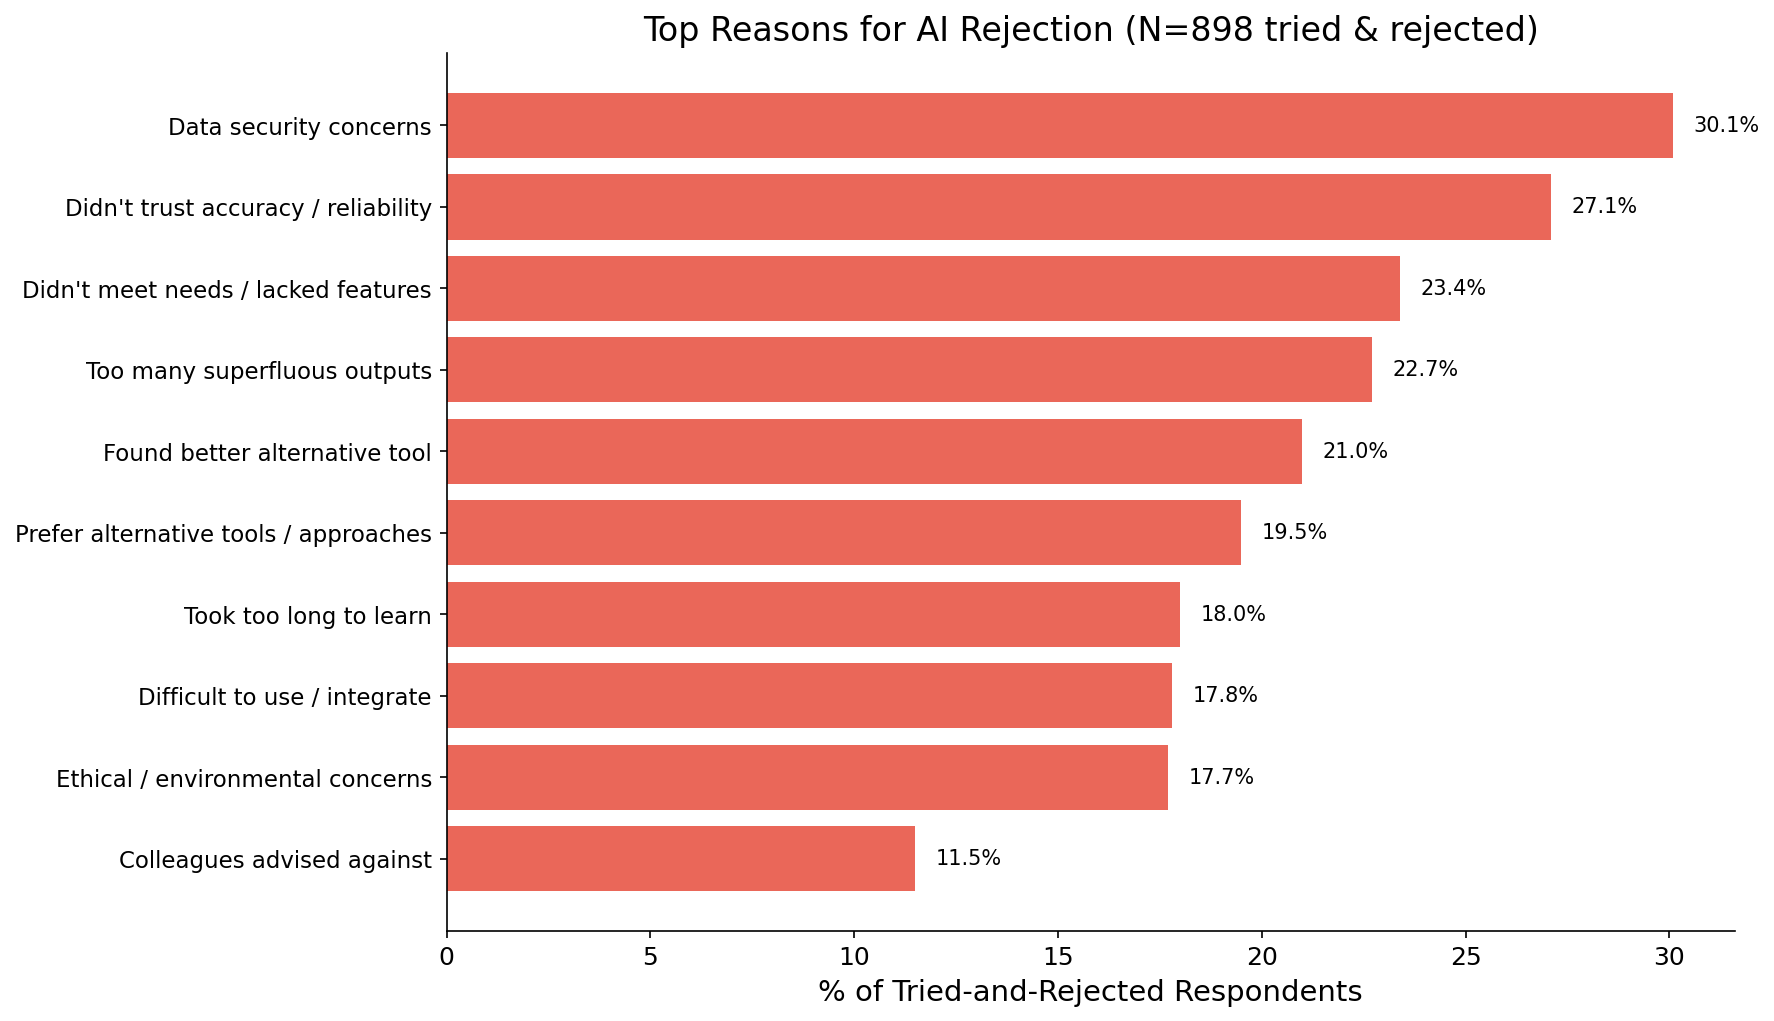

In [28]:
# =============================================================================
# F.5 Q12 TOP REASONS BAR CHART
# =============================================================================
top_reasons = q12_reasons_df.head(10)

fig, ax = plt.subplots(figsize=(12, 7))

y_pos = np.arange(len(top_reasons))
ax.barh(y_pos, top_reasons['Percent_of_Tried_Rejected'], color=ACCENT_COLOR, alpha=0.85)

ax.set_yticks(y_pos)
ax.set_yticklabels(top_reasons['Reason'], fontsize=11)
ax.set_xlabel('% of Tried-and-Rejected Respondents', fontsize=14)
ax.set_title(f'Top Reasons for AI Rejection (N={denominator_n:,} tried & rejected)', fontsize=16)

# Add value labels
for i, (n, pct) in enumerate(zip(top_reasons['N'], top_reasons['Percent_of_Tried_Rejected'])):
    ax.text(pct + 0.5, i, f'{pct}%', va='center', fontsize=10)

ax.invert_yaxis()
plt.tight_layout()
plt.show()

## G. Open-Text Corpus (Q13-Q14)

In [29]:
# =============================================================================
# G.1 OPEN TEXT NON-EMPTY COUNTS
# =============================================================================

# Q13: Tasks delegated to AI
q13_non_empty = survey[Q13_OPEN_COL].notna() & (survey[Q13_OPEN_COL].astype(str).str.strip() != '')
q13_count = q13_non_empty.sum()

# Q14: Tasks enabled by AI
q14_non_empty = survey[Q14_OPEN_COL].notna() & (survey[Q14_OPEN_COL].astype(str).str.strip() != '')
q14_count = q14_non_empty.sum()

print("Open-text response counts:")
print(f"  Q13 (tasks delegated to AI): {q13_count:,} non-empty responses")
print(f"  Q14 (tasks enabled by AI): {q14_count:,} non-empty responses")

# Sample responses
print("\nQ13 sample responses:")
for resp in survey.loc[q13_non_empty, Q13_OPEN_COL].head(5):
    print(f"  - {str(resp)[:100]}{'...' if len(str(resp)) > 100 else ''}")

print("\nQ14 sample responses:")
for resp in survey.loc[q14_non_empty, Q14_OPEN_COL].head(5):
    print(f"  - {str(resp)[:100]}{'...' if len(str(resp)) > 100 else ''}")

Open-text response counts:
  Q13 (tasks delegated to AI): 1,399 non-empty responses
  Q14 (tasks enabled by AI): 1,201 non-empty responses

Q13 sample responses:
  - Administrative tasks
  - Content writing, editing of videos
  - Writing report and summary
  - Administrative task
  - Scheduling interviews, conducting interviews, hiring new talent, matching takent with suitable vacan...

Q14 sample responses:
  - Administrative tasks
  - Making beautiful flyers for promotion
  - Administrative assistant
  - I can make rotation list for all employees based pn their usual shift time and/or expertise, which w...
  - Image Generation|Running Code


In [30]:
# =============================================================================
# G.2 EXPORT OPEN TEXT RESPONSES
# =============================================================================

# Create unified role column (from sector-specific role columns)
role_col_map = {
    'Information Technology (IT)': 'Sector4.a',  # IT roles
    'Financial Services': 'Sector1.a',           # Finance roles
    'Education': 'Sector2.a',                    # Education roles
    'Healthcare Services': 'Sector3.a',          # Healthcare roles
}

def get_role(row):
    """Get role from the appropriate sector-specific column."""
    sector = row.get(SECTOR_COL)
    if pd.isna(sector):
        return None
    role_col = role_col_map.get(sector)
    if role_col and role_col in row.index:
        return row.get(role_col)
    return None

survey['role'] = survey.apply(get_role, axis=1)

# Export respondent-level open-text dataset
open_text_export = survey[[
    SECTOR_COL,
    'role',
    Q13_OPEN_COL,
    Q14_OPEN_COL
]].copy()

open_text_export.columns = ['sector', 'role', 'q13_tasks_delegated', 'q14_tasks_enabled']

# Filter using the SAME non-empty masks computed earlier (not just .notna())
# This ensures consistency and excludes empty strings/whitespace
q13_export_valid = open_text_export['q13_tasks_delegated'].notna() & \
                   (open_text_export['q13_tasks_delegated'].astype(str).str.strip() != '')
q14_export_valid = open_text_export['q14_tasks_enabled'].notna() & \
                   (open_text_export['q14_tasks_enabled'].astype(str).str.strip() != '')

has_open_text = q13_export_valid | q14_export_valid
open_text_export = open_text_export[has_open_text]

print(f"Exporting {len(open_text_export):,} rows with non-empty open-text responses")
print(f"  (Q13 non-empty: {q13_export_valid.sum():,}, Q14 non-empty: {q14_export_valid.sum():,})")

# Save
open_text_export.to_csv(OUT_DIR / "open_text_responses.csv", index=False)
print(f"\nSaved: {OUT_DIR / 'open_text_responses.csv'}")

Exporting 1,509 rows with non-empty open-text responses
  (Q13 non-empty: 1,399, Q14 non-empty: 1,201)

Saved: outputs/survey_only/open_text_responses.csv


---

**Next notebook** maps these open-text task descriptions to O*NET task statements for taxonomy alignment and mismatch analysis.

## H. Topline Visualisations

Slide-ready summary charts for key findings.

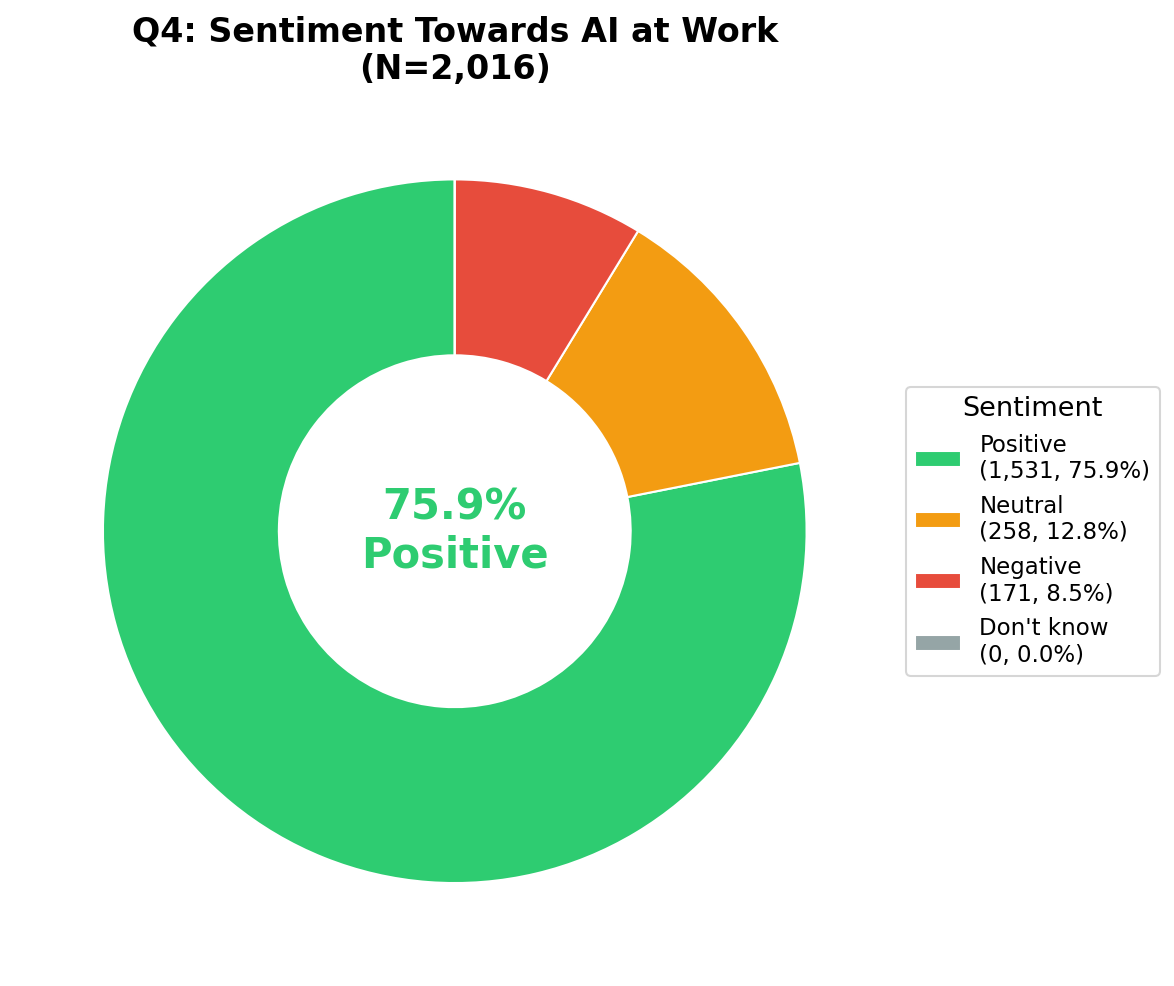

In [31]:
# =============================================================================
# H.1 SENTIMENT DONUT CHART
# =============================================================================
fig, ax = plt.subplots(figsize=(8, 8))

# Group responses for cleaner visualization
sentiment_groups = {
    'Positive': positive_sentiment,
    'Neutral': neutral_sentiment,
    'Negative': negative_sentiment,
    "Don't know": (survey[Q4_COL] == "Don't know").sum()
}

colors = ['#2ECC71', '#F39C12', '#E74C3C', '#95A5A6']
sizes = list(sentiment_groups.values())
labels = [f'{k}\n({v:,}, {round(v/total_n*100, 1)}%)' for k, v in sentiment_groups.items()]

wedges, texts = ax.pie(sizes, colors=colors, startangle=90, 
                       wedgeprops=dict(width=0.5, edgecolor='white'))

ax.legend(wedges, labels, title="Sentiment", loc="center left", 
          bbox_to_anchor=(1, 0, 0.5, 1), fontsize=11)

ax.set_title('Q4: Sentiment Towards AI at Work\n(N=2,016)', fontsize=16, fontweight='bold')

# Center text
ax.text(0, 0, f'{positive_pct}%\nPositive', ha='center', va='center', 
        fontsize=20, fontweight='bold', color='#2ECC71')

plt.tight_layout()
plt.savefig(OUT_DIR / "fig_sentiment_donut.png", dpi=150, bbox_inches='tight')
plt.show()

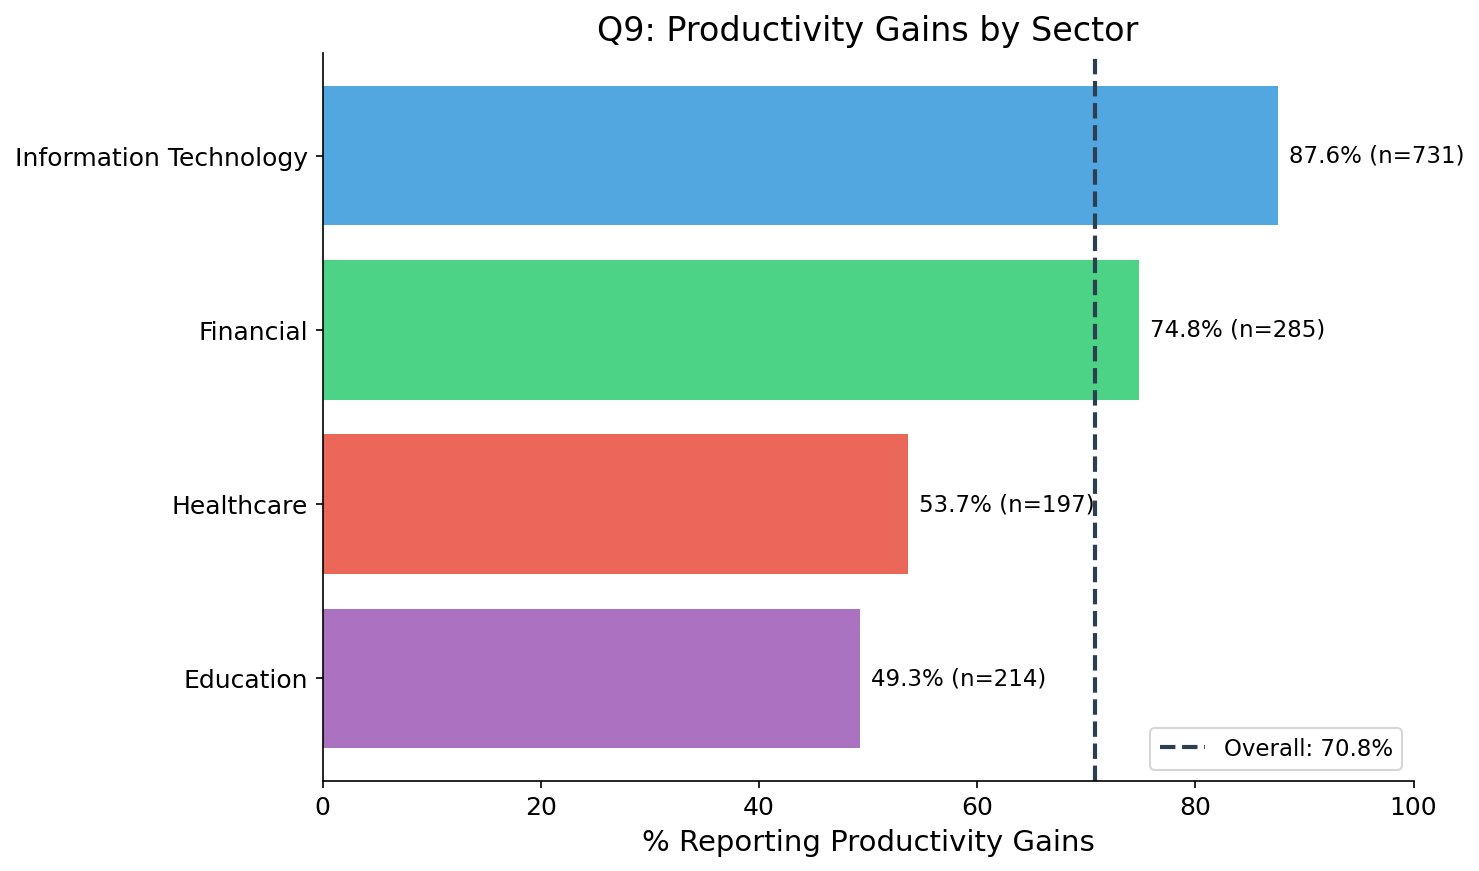

In [32]:
# =============================================================================
# H.2 PRODUCTIVITY GAINS BY SECTOR
# =============================================================================
fig, ax = plt.subplots(figsize=(10, 6))

# Calculate productivity gains by sector
productivity_by_sector = []
for sector in ['Information Technology (IT)', 'Financial Services', 'Education', 'Healthcare Services']:
    sector_df_temp = survey[survey[SECTOR_COL] == sector]
    sector_productive = (sector_df_temp[Q9_COL] == MORE_PRODUCTIVE).sum()
    sector_pct = round(sector_productive / len(sector_df_temp) * 100, 1)
    productivity_by_sector.append({
        'Sector': sector.replace(' Services', '').replace(' (IT)', ''),
        'Percent': sector_pct,
        'N': sector_productive,
        'Color': SECTOR_COLORS.get(sector, '#7F8C8D')
    })

prod_df = pd.DataFrame(productivity_by_sector).sort_values('Percent', ascending=True)

y_pos = range(len(prod_df))
bars = ax.barh(y_pos, prod_df['Percent'], color=prod_df['Color'].values, alpha=0.85)

ax.set_yticks(y_pos)
ax.set_yticklabels(prod_df['Sector'], fontsize=12)
ax.set_xlabel('% Reporting Productivity Gains', fontsize=14)
ax.set_title('Q9: Productivity Gains by Sector', fontsize=16)
ax.set_xlim(0, 100)

# Add value labels
for bar, pct, n in zip(bars, prod_df['Percent'], prod_df['N']):
    ax.text(pct + 1, bar.get_y() + bar.get_height()/2, 
            f'{pct}% (n={n})', va='center', fontsize=11)

# Add overall average line
ax.axvline(x=productivity_gain_pct, color='#2C3E50', linestyle='--', linewidth=2, label=f'Overall: {productivity_gain_pct}%')
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig(OUT_DIR / "fig_productivity_by_sector.png", dpi=150, bbox_inches='tight')
plt.show()

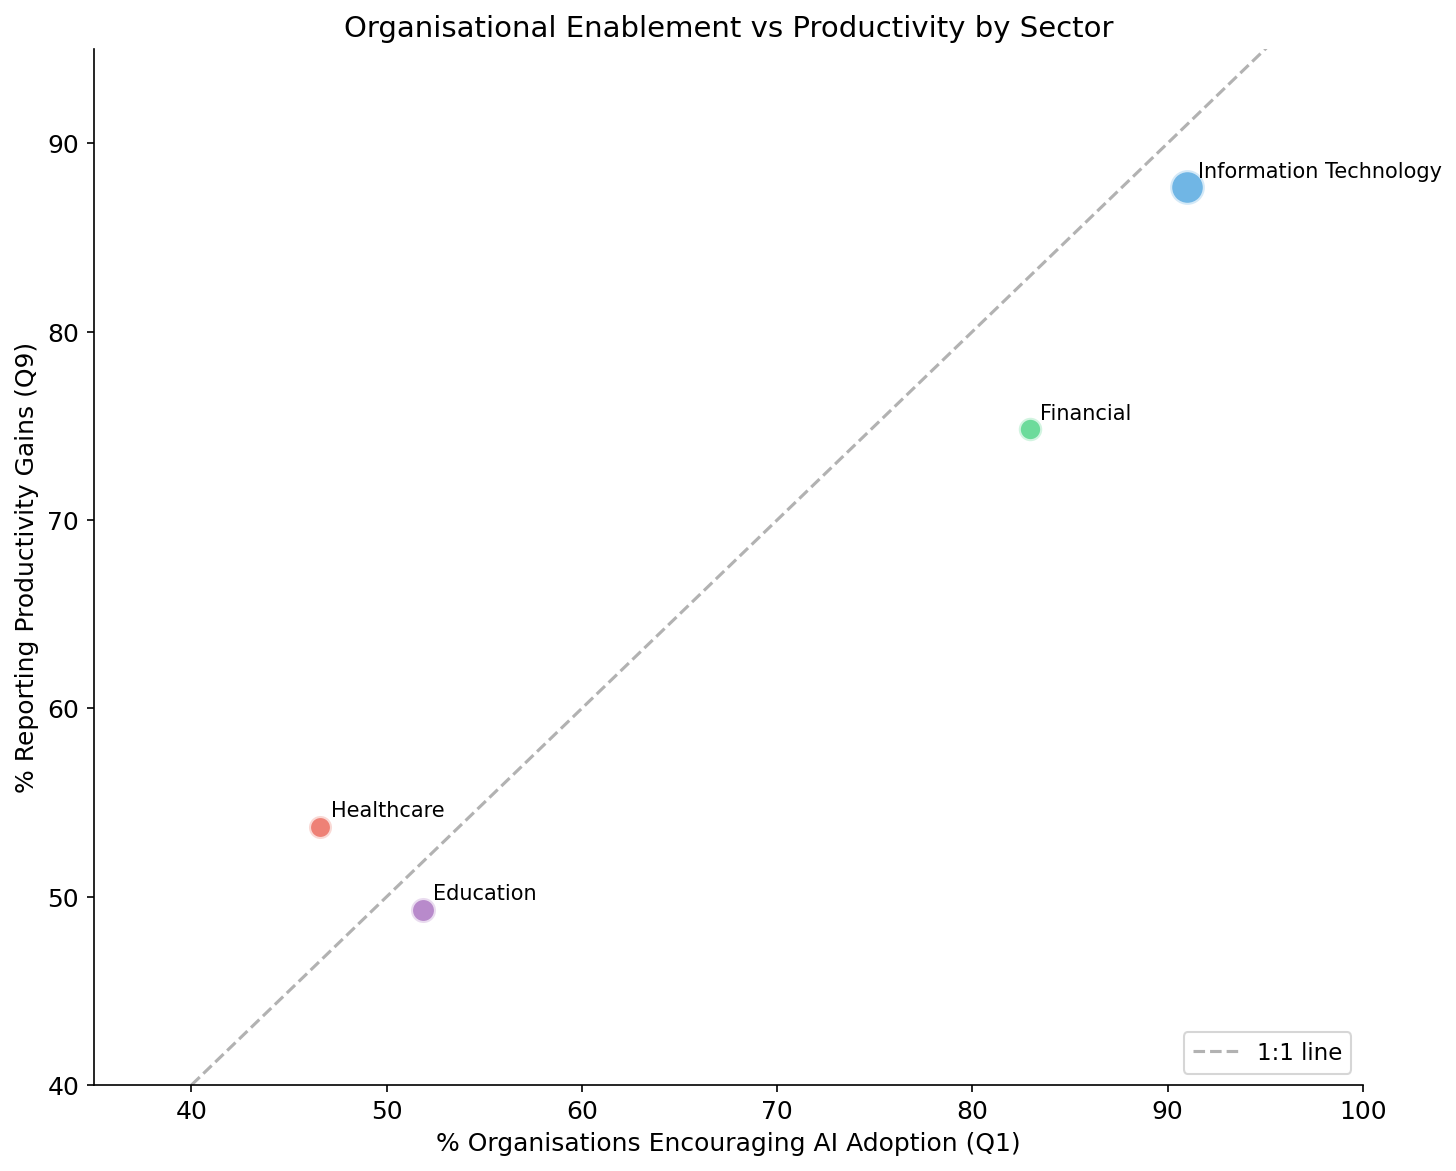

In [33]:
# =============================================================================
# H.3 ORGANISATIONAL ENABLEMENT VS PRODUCTIVITY (BY SECTOR)
# =============================================================================
fig, ax = plt.subplots(figsize=(10, 8))

# Calculate encouragement and productivity by sector
scatter_data = []
for sector in survey[SECTOR_COL].dropna().unique():
    sector_df_temp = survey[survey[SECTOR_COL] == sector]
    n = len(sector_df_temp)
    
    # Encouragement rate (strongly + somewhat)
    encouragement = sector_df_temp[Q1_COL].isin([
        'Strongly encourages AI adoption', 
        'Somewhat encourages AI adoption'
    ]).sum() / n * 100
    
    # Productivity rate
    productivity = (sector_df_temp[Q9_COL] == MORE_PRODUCTIVE).sum() / n * 100
    
    scatter_data.append({
        'Sector': sector,
        'Encouragement': encouragement,
        'Productivity': productivity,
        'N': n,
        'Color': SECTOR_COLORS.get(sector, '#7F8C8D')
    })

scatter_df = pd.DataFrame(scatter_data)

# Plot
for _, row in scatter_df.iterrows():
    ax.scatter(row['Encouragement'], row['Productivity'], 
               s=row['N']/3, c=row['Color'], alpha=0.7, edgecolors='white', linewidth=2)
    ax.annotate(row['Sector'].replace(' Services', '').replace(' (IT)', ''), 
                (row['Encouragement'], row['Productivity']),
                xytext=(5, 5), textcoords='offset points', fontsize=10)

ax.set_xlabel('% Organisations Encouraging AI Adoption (Q1)', fontsize=12)
ax.set_ylabel('% Reporting Productivity Gains (Q9)', fontsize=12)
ax.set_title('Organisational Enablement vs Productivity by Sector', fontsize=14)

# Add trend indication
ax.plot([40, 100], [40, 100], 'k--', alpha=0.3, label='1:1 line')

ax.set_xlim(35, 100)
ax.set_ylim(40, 95)
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig(OUT_DIR / "fig_enablement_vs_productivity.png", dpi=150, bbox_inches='tight')
plt.show()

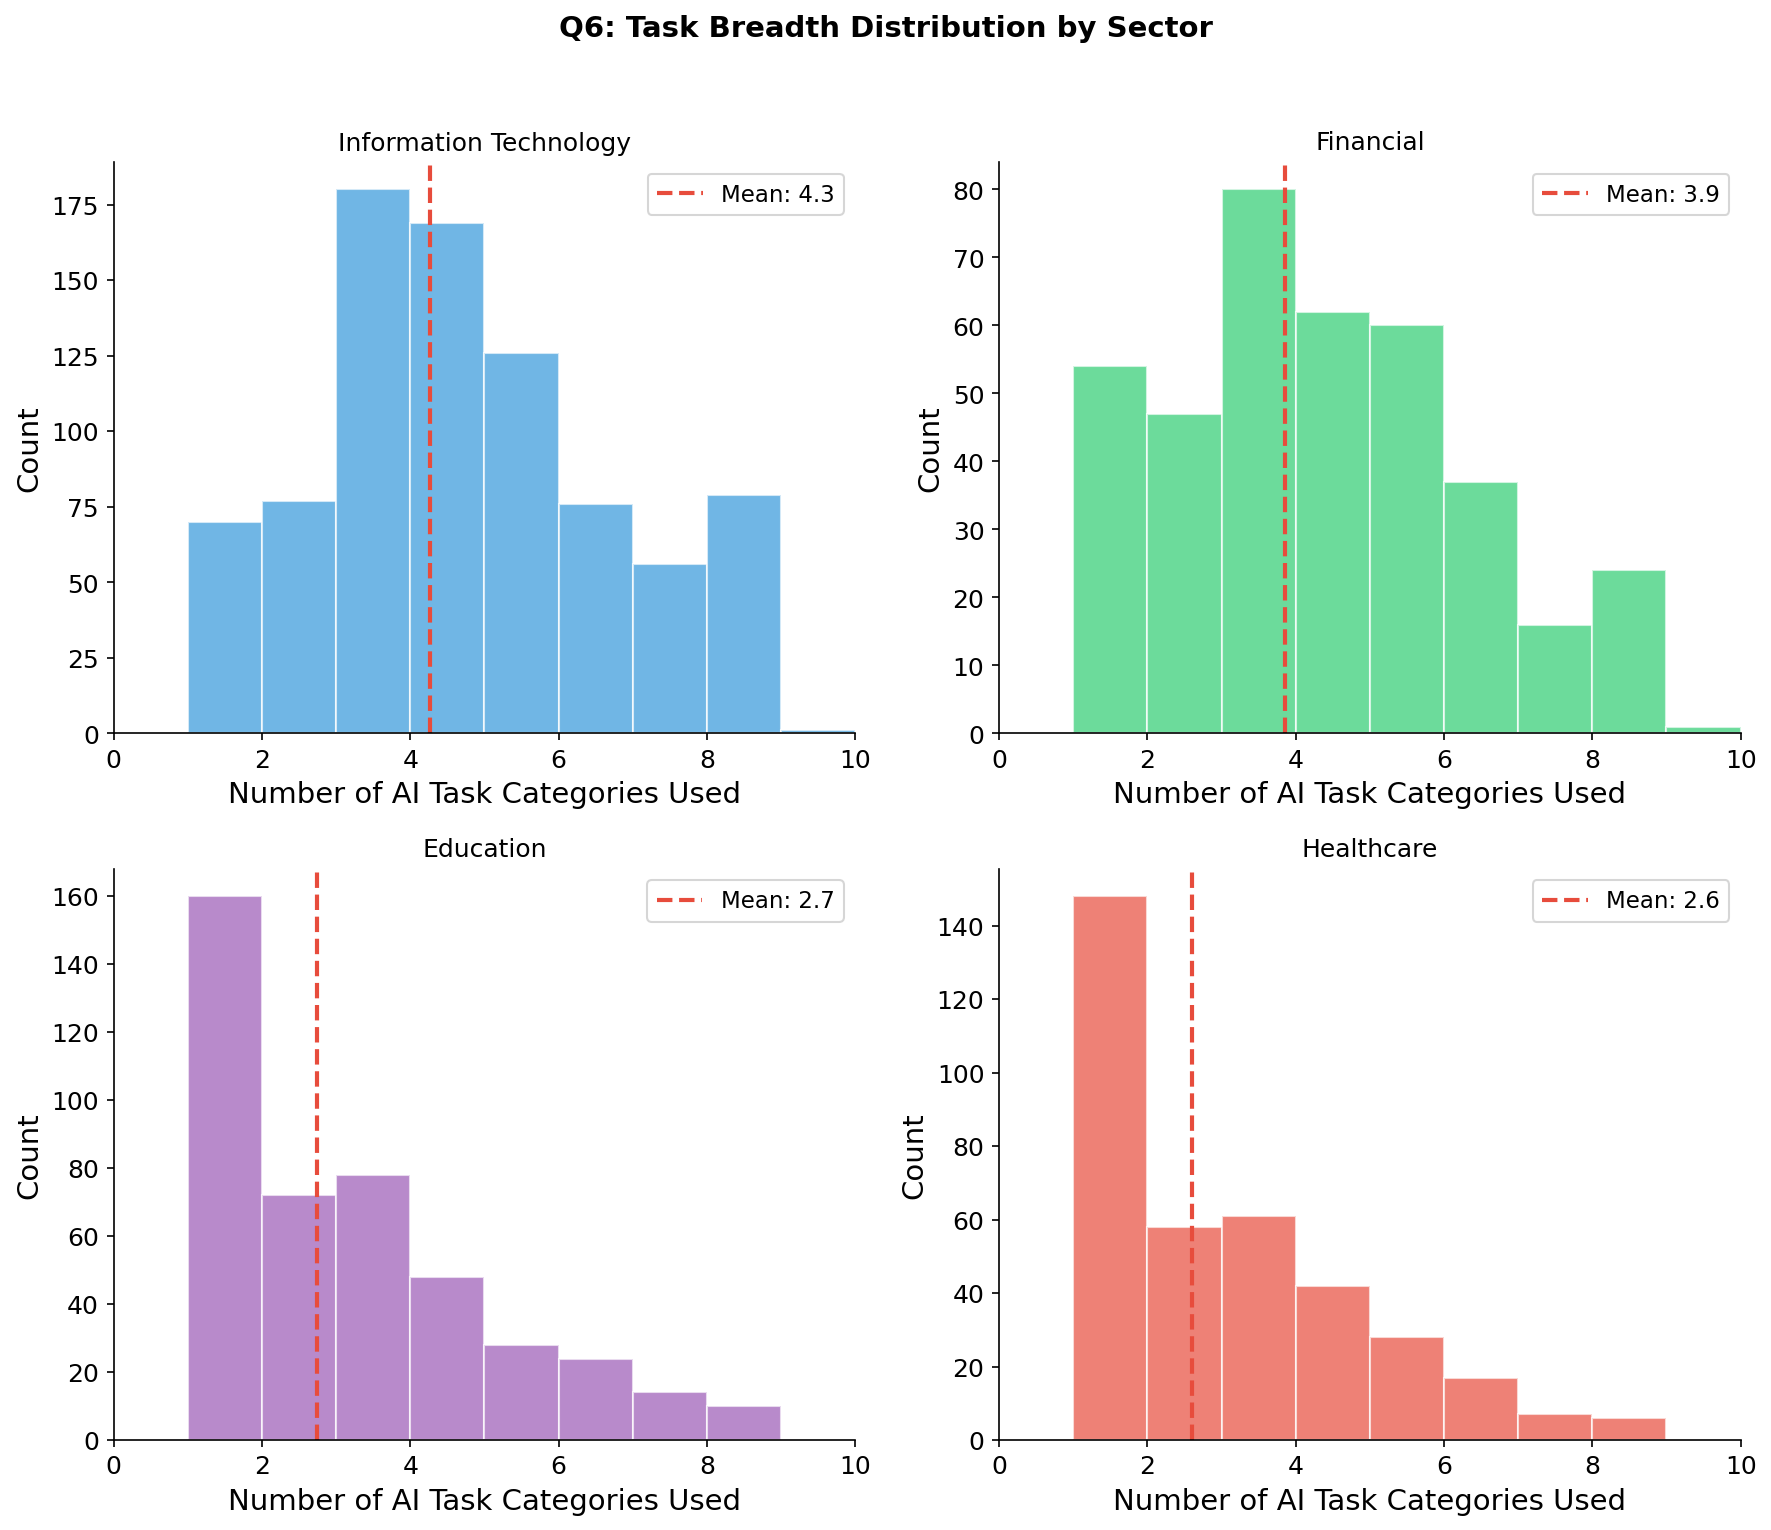

In [34]:
# =============================================================================
# H.4 TASK BREADTH DISTRIBUTION BY SECTOR
# =============================================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

sector_order = ['Information Technology (IT)', 'Financial Services', 'Education', 'Healthcare Services']

for idx, sector in enumerate(sector_order):
    ax = axes[idx]
    sector_data = survey[survey[SECTOR_COL] == sector]['q6_task_breadth']
    
    # Histogram
    ax.hist(sector_data, bins=range(0, 11), alpha=0.7, 
            color=SECTOR_COLORS.get(sector, '#7F8C8D'), edgecolor='white')
    
    mean_val = sector_data.mean()
    ax.axvline(x=mean_val, color='#E74C3C', linestyle='--', linewidth=2, 
               label=f'Mean: {mean_val:.1f}')
    
    ax.set_title(sector.replace(' Services', '').replace(' (IT)', ''), fontsize=12)
    ax.set_xlabel('Number of AI Task Categories Used')
    ax.set_ylabel('Count')
    ax.legend(loc='upper right')
    ax.set_xlim(0, 10)

fig.suptitle('Q6: Task Breadth Distribution by Sector', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / "fig_task_breadth_by_sector.png", dpi=150, bbox_inches='tight')
plt.show()

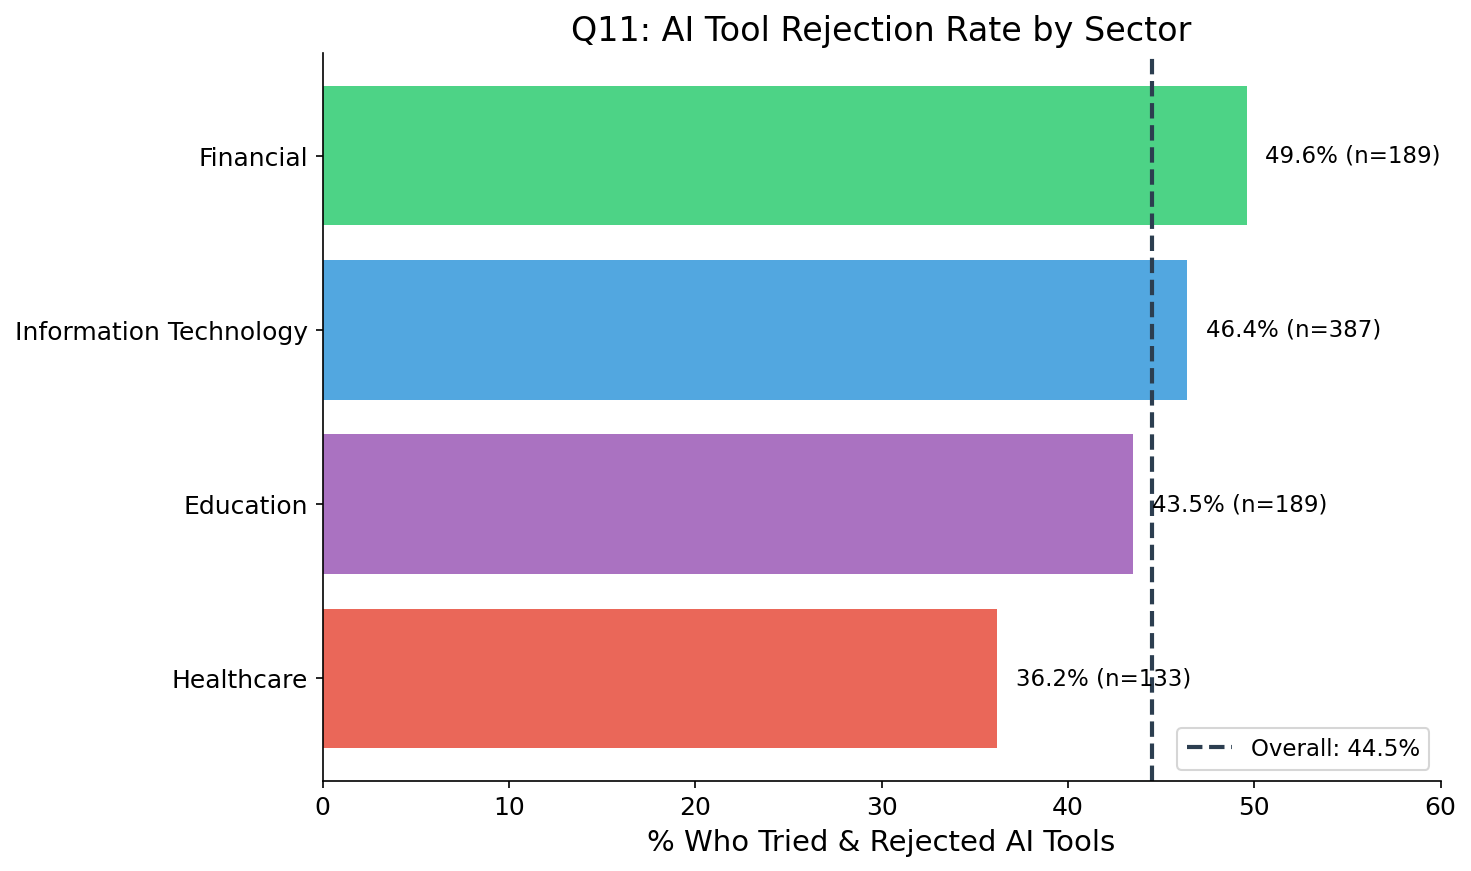

In [35]:
# =============================================================================
# H.5 REJECTION RATE BY SECTOR
# =============================================================================
fig, ax = plt.subplots(figsize=(10, 6))

# Calculate rejection rates
rejection_by_sector = []
for sector in ['Financial Services', 'Information Technology (IT)', 'Education', 'Healthcare Services']:
    sector_df_temp = survey[survey[SECTOR_COL] == sector]
    n = len(sector_df_temp)
    rejected = (sector_df_temp[Q11_COL] == TRIED_REJECTED).sum()
    pct = round(rejected / n * 100, 1)
    rejection_by_sector.append({
        'Sector': sector.replace(' Services', '').replace(' (IT)', ''),
        'Percent': pct,
        'N': rejected,
        'Color': SECTOR_COLORS.get(sector, '#7F8C8D')
    })

rej_df = pd.DataFrame(rejection_by_sector).sort_values('Percent', ascending=True)

y_pos = range(len(rej_df))
bars = ax.barh(y_pos, rej_df['Percent'], color=rej_df['Color'].values, alpha=0.85)

ax.set_yticks(y_pos)
ax.set_yticklabels(rej_df['Sector'], fontsize=12)
ax.set_xlabel('% Who Tried & Rejected AI Tools', fontsize=14)
ax.set_title('Q11: AI Tool Rejection Rate by Sector', fontsize=16)
ax.set_xlim(0, 60)

# Add value labels
for bar, pct, n in zip(bars, rej_df['Percent'], rej_df['N']):
    ax.text(pct + 1, bar.get_y() + bar.get_height()/2, 
            f'{pct}% (n={n})', va='center', fontsize=11)

# Add overall average line
ax.axvline(x=tried_rejected_pct, color='#2C3E50', linestyle='--', linewidth=2, 
           label=f'Overall: {tried_rejected_pct}%')
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig(OUT_DIR / "fig_rejection_by_sector.png", dpi=150, bbox_inches='tight')
plt.show()

## I. Toplines Summary

In [36]:
# =============================================================================
# I. CREATE TOPLINES.TXT
# =============================================================================

# Gather all headline values
toplines = []
toplines.append("SURVATION AI WORKFORCE SURVEY - TOPLINES")
toplines.append("=" * 60)
toplines.append(f"Generated from notebook 04_survey_analysis.ipynb")
toplines.append("")

# Sample
toplines.append("SAMPLE")
toplines.append(f"  Total N: {total_n:,}")
toplines.append("  Sector Ns:")
for _, row in sector_df.iterrows():
    toplines.append(f"    {row['Sector']}: {row['N']:,} ({row['Percent']}%)")
toplines.append("")

# Q1 Organisational enablement
toplines.append("Q1: ORGANISATIONAL ENABLEMENT")
strongly_encourages = q1_overall_df[q1_overall_df['Response'] == 'Strongly encourages AI adoption']
if len(strongly_encourages) > 0:
    n, pct = strongly_encourages.iloc[0]['N'], strongly_encourages.iloc[0]['Percent']
    toplines.append(f"  Strongly encourages AI adoption: {n:,} ({pct}%)")
# Calculate total encouragement
encourages_mask = survey[Q1_COL].isin(['Strongly encourages AI adoption', 'Somewhat encourages AI adoption'])
encourages_total = encourages_mask.sum()
encourages_pct = round(encourages_total / total_n * 100, 1)
toplines.append(f"  Any encouragement (strongly + somewhat): {encourages_total:,} ({encourages_pct}%)")
toplines.append("")

# Q4 Sentiment (using exact matching)
toplines.append("Q4: SENTIMENT")
toplines.append(f"  Positive sentiment (Extremely + Somewhat): {positive_sentiment:,} ({positive_pct}%)")
toplines.append(f"  Negative sentiment (Extremely + Somewhat): {negative_sentiment:,} ({negative_pct}%)")
toplines.append(f"  Neutral sentiment: {neutral_sentiment:,} ({neutral_pct}%)")
toplines.append("")

# Q6 Task breadth
toplines.append("Q6: TASK USAGE")
toplines.append(f"  Mean task breadth (categories selected): {overall_mean_breadth:.2f}")
toplines.append("  Task breadth by sector:")
for sector, row in breadth_by_sector.iterrows():
    toplines.append(f"    {sector}: {row['Mean_Breadth']:.2f}")
toplines.append("")

# Q9 Productivity
toplines.append("Q9: PRODUCTIVITY")
toplines.append(f"  More productive: {productivity_gain_n:,} ({productivity_gain_pct}%)")
toplines.append("  Productivity gains by sector:")
for sector in ['Information Technology (IT)', 'Financial Services', 'Education', 'Healthcare Services']:
    sector_df_temp = survey[survey[SECTOR_COL] == sector]
    sector_productive = (sector_df_temp[Q9_COL] == MORE_PRODUCTIVE).sum()
    sector_pct = round(sector_productive / len(sector_df_temp) * 100, 1)
    toplines.append(f"    {sector}: {sector_productive:,} ({sector_pct}%)")
toplines.append("")

# Q11 Rejection
toplines.append("Q11: REJECTION STATUS")
toplines.append(f"  Tried and rejected: {tried_rejected_n:,} ({tried_rejected_pct}%)")
toplines.append(f"  Never tried: {never_tried_n:,} ({never_tried_pct}%)")
toplines.append("  Tried-and-rejected by sector:")
for sector in ['Financial Services', 'Information Technology (IT)', 'Education', 'Healthcare Services']:
    sector_n = survey[survey[SECTOR_COL] == sector].shape[0]
    sector_rejected = survey[(survey[SECTOR_COL] == sector) & (survey[Q11_COL] == TRIED_REJECTED)].shape[0]
    pct = round(sector_rejected / sector_n * 100, 1)
    toplines.append(f"    {sector}: {sector_rejected:,} ({pct}%)")
toplines.append("")

# Top rejection reasons
toplines.append("Q12: TOP REJECTION REASONS (among tried-and-rejected)")
for _, row in q12_reasons_df.head(5).iterrows():
    toplines.append(f"  {row['Reason']}: {row['Percent_of_Tried_Rejected']}%")
toplines.append("")

# Q13/Q14 Open text
toplines.append("Q13-Q14: OPEN TEXT")
toplines.append(f"  Q13 non-empty (tasks delegated): {q13_count:,}")
toplines.append(f"  Q14 non-empty (tasks enabled): {q14_count:,}")
toplines.append("")

# Charts generated
toplines.append("CHARTS GENERATED")
chart_files = [
    "fig_sector_composition.png",
    "fig_sentiment_donut.png",
    "fig_productivity_by_sector.png",
    "fig_enablement_vs_productivity.png",
    "fig_task_breadth_by_sector.png",
    "fig_rejection_by_sector.png",
]
for f in chart_files:
    path = OUT_DIR / f
    status = "OK" if path.exists() else "PENDING"
    toplines.append(f"  [{status}] {f}")
toplines.append("")

# Write to file
toplines_path = OUT_DIR / "toplines.txt"
with open(toplines_path, 'w') as f:
    f.write('\n'.join(toplines))

print("TOPLINES SUMMARY")
print("=" * 60)
print('\n'.join(toplines))
print(f"\nSaved: {toplines_path}")

TOPLINES SUMMARY
SURVATION AI WORKFORCE SURVEY - TOPLINES
Generated from notebook 04_survey_analysis.ipynb

SAMPLE
  Total N: 2,016
  Sector Ns:
    Information Technology (IT): 834 (41.4%)
    Education: 434 (21.5%)
    Financial Services: 381 (18.9%)
    Healthcare Services: 367 (18.2%)

Q1: ORGANISATIONAL ENABLEMENT
  Strongly encourages AI adoption: 909 (45.1%)
  Any encouragement (strongly + somewhat): 1,471 (73.0%)

Q4: SENTIMENT
  Positive sentiment (Extremely + Somewhat): 1,531 (75.9%)
  Negative sentiment (Extremely + Somewhat): 171 (8.5%)
  Neutral sentiment: 258 (12.8%)

Q6: TASK USAGE
  Mean task breadth (categories selected): 3.56
  Task breadth by sector:
    Education: 2.75
    Financial Services: 3.86
    Healthcare Services: 2.60
    Information Technology (IT): 4.27

Q9: PRODUCTIVITY
  More productive: 1,427 (70.8%)
  Productivity gains by sector:
    Information Technology (IT): 731 (87.6%)
    Financial Services: 285 (74.8%)
    Education: 214 (49.3%)
    Healthcare

In [37]:
# =============================================================================
# I.2 GENERATE SUMMARY NARRATIVE MARKDOWN
# =============================================================================

summary_md = f"""# AI Workforce Survey Analysis: Summary Report

**Survey**: Survation AI Workforce Survey, January 2026  
**Sample**: N = {total_n:,} UK workers across four sectors  
**Analysis notebook**: `04_survey_analysis.ipynb`

---

## Executive Summary

This report presents descriptive findings from a survey-first analysis of AI adoption patterns, sentiment, productivity outcomes, and barriers across four UK sectors.

### Key Findings at a Glance

| Metric | Overall | IT | Finance | Education | Healthcare |
|--------|---------|-----|---------|-----------|------------|
| **Positive sentiment** | {positive_pct}% | 91.5% | 81.6% | 58.3% | 55.6% |
| **Productivity gains** | {productivity_gain_pct}% | 87.6% | 74.8% | 49.3% | 53.7% |
| **Tried & rejected** | {tried_rejected_pct}% | 46.4% | 49.6% | 43.5% | 36.2% |
| **Task breadth (mean)** | {overall_mean_breadth:.2f} | 4.27 | 3.86 | 2.75 | 2.60 |

---

## 1. Sample Composition

Total N = {total_n:,} responses across four sectors.

---

## 2. Organisational Enablement (Q1)

- **{encourages_pct}%** report organisational encouragement (strongly + somewhat)
- IT (91.0%) and Finance (83.0%) show high enablement
- Education (51.9%) and Healthcare (46.5%) show lower enablement

---

## 3. Sentiment Towards AI (Q4)

- **Positive sentiment**: {positive_sentiment:,} ({positive_pct}%)
- **Negative sentiment**: {negative_sentiment:,} ({negative_pct}%)
- **Neutral sentiment**: {neutral_sentiment:,} ({neutral_pct}%)

---

## 4. Productivity Outcomes (Q9)

- **{productivity_gain_pct}%** report AI has made them more productive
- Strong association with organisational enablement

---

## 5. Rejection and Barriers (Q11-Q12)

- **{tried_rejected_pct}%** have tried and rejected an AI tool
- Top reasons: Data security, Accuracy concerns, Didn't meet needs

---

## 6. Open-Text Corpus

- **Q13** (tasks delegated): {q13_count:,} non-empty responses
- **Q14** (tasks enabled): {q14_count:,} non-empty responses

---

*Generated from notebook 04_survey_analysis.ipynb*
"""

# Write summary markdown
summary_path = OUT_DIR / "SURVEY_ANALYSIS_SUMMARY.md"
with open(summary_path, 'w') as f:
    f.write(summary_md)

print(f"Summary narrative saved to: {summary_path}")

Summary narrative saved to: outputs/survey_only/SURVEY_ANALYSIS_SUMMARY.md


## J. QC Check

In [38]:
# =============================================================================
# J. FINAL QC CHECK
# =============================================================================

print("=" * 70)
print("QC CHECK")
print("=" * 70)

# 1. Total N
print(f"\n1. Total N: {total_n:,}")

# 2. Sector Ns
print(f"\n2. Sector Ns:")
sector_check = survey[SECTOR_COL].value_counts()
for sector, n in sector_check.items():
    print(f"   {sector}: {n:,}")
print(f"   Sum: {sector_check.sum():,}")

# 3. Q11 category counts
print(f"\n3. Q11 category counts:")
q11_check = survey[Q11_COL].value_counts()
for cat, n in q11_check.items():
    print(f"   {cat}: {n:,}")
print(f"   Sum: {q11_check.sum():,}")

# 4. Q6 columns detected and labeled
print(f"\n4. Q6 columns detected: {len(q6_task_cols)}")
for col in q6_task_cols:
    label = Q6_LABELS.get(col, 'MISSING LABEL')
    print(f"   {col} -> {label}")

# 5. Q13/Q14 non-empty counts
print(f"\n5. Open-text non-empty counts:")
print(f"   Q13: {q13_count:,}")
print(f"   Q14: {q14_count:,}")

# 6. Sentiment verification (exact matching)
print(f"\n6. Sentiment verification (exact matching):")
print(f"   Positive: {positive_sentiment:,} ({positive_pct}%)")
print(f"   Negative: {negative_sentiment:,} ({negative_pct}%)")
print(f"   Neutral: {neutral_sentiment:,} ({neutral_pct}%)")
sentiment_total = positive_sentiment + negative_sentiment + neutral_sentiment + (survey[Q4_COL] == "Don't know").sum()
print(f"   Total (incl. Don't know): {sentiment_total:,}")

# 7. Paths written
print(f"\n7. Output files written:")
expected_files = [
    # Data tables
    'sector_counts.csv',
    'q1_org_encouragement_overall.csv',
    'q1_org_encouragement_by_sector.csv',
    'q4_sentiment_overall.csv',
    'q4_sentiment_by_sector.csv',
    'q6_task_use_by_sector.csv',
    'q6_task_breadth.csv',
    'q6_task_breadth_by_sector.csv',
    'q9_productivity_overall.csv',
    'q9_productivity_by_sector.csv',
    'q1_q9_crosstab.csv',
    'q11_rejection_overall.csv',
    'q11_rejection_by_sector.csv',
    'q12_reasons_overall.csv',
    'q12_reasons_by_sector.csv',
    'open_text_responses.csv',
    # Summary files
    'toplines.txt',
    'SURVEY_ANALYSIS_SUMMARY.md',
    # Charts
    'fig_sector_composition.png',
    'fig_sentiment_donut.png',
    'fig_productivity_by_sector.png',
    'fig_enablement_vs_productivity.png',
    'fig_task_breadth_by_sector.png',
    'fig_rejection_by_sector.png',
]

for f in expected_files:
    path = OUT_DIR / f
    exists = path.exists()
    status = "OK" if exists else "MISSING"
    print(f"   [{status}] {f}")

# Summary
all_ok = all((OUT_DIR / f).exists() for f in expected_files)
print(f"\n{'=' * 70}")
print(f"QC STATUS: {'PASS' if all_ok else 'FAIL'}")
print(f"{'=' * 70}")

QC CHECK

1. Total N: 2,016

2. Sector Ns:
   Information Technology (IT): 834
   Education: 434
   Financial Services: 381
   Healthcare Services: 367
   Sum: 2,016

3. Q11 category counts:
   I have tried an AI tool and decided against adopting/using it: 898
   I have never tried an AI tool and decided against adopting/using it: 837
   I can’t remember: 281
   Sum: 2,016

4. Q6 columns detected: 9
   q6.a.1 -> Drafting and editing documents
   q6.a.2 -> Data analysis and visualisation
   q6.a.3 -> Searching for and summarising information
   q6.a.4 -> Administrative tasks
   q6.a.5 -> Communication support
   q6.a.6 -> Creative work
   q6.a.7 -> Technical/specialised outputs
   q6.a.8 -> Professional development
   q6.a.9 -> Other

5. Open-text non-empty counts:
   Q13: 1,399
   Q14: 1,201

6. Sentiment verification (exact matching):
   Positive: 1,531 (75.9%)
   Negative: 171 (8.5%)
   Neutral: 258 (12.8%)
   Total (incl. Don't know): 1,960

7. Output files written:
   [OK] sector_c